Cài đặt thư viện d2l

In [2]:
# d2l library already available via import


# Long Short-Term Memory (LSTM)

Mạng bộ nhớ dài-ngắn (Long Short Term Memory networks), thường được gọi là LSTM - là một dạng đặc biệt của RNN, nó có khả năng học được các phụ thuộc xa. LSTM được giới thiệu bởi Hochreiter & Schmidhuber (1997), và sau đó đã được cải tiến và phổ biến cho tới ngày nay.


## Gated Memory Cell

Thiết kế của LSTM được lấy cảm hứng từ các cổng logic của máy tính. LSTM giới thiệu memory cell (gọi twats là cell) có hình dạng giống như hidden state (một số tài liệu coi ô nhớ là một loại hidden state đặc biệt), được thiết kế để nhớ thông tin. Để điều khiên memory cell, ta cần một số cống. Cần có 1 cổng để lấy ra thông tin từ memory cell, ta gọi là *output gate*. Một cổng thứ 2 để quyết định thông tin được lưu vào memory cell, gọi là *input gate*. Cuối cùng ta cần một cơ chế để quyết định nên bỏ đi thông tin gì từ memory cell, ta gọi là *forget gate*.

### Input Gate, Forget Gate, and Output Gate

Just like in GRUs,
the data feeding into the LSTM gates are
the input at the current time step and
the hidden state of the previous time step,
as illustrated in :numref:`lstm_0`.
They are processed by
three fully-connected layers with a sigmoid activation function to compute the values of
the input, forget. and output gates.
As a result, values of the three gates
are in the range of $(0, 1)$.

Giống như trong GRU, dữ liệu đưa vào LSTM là đầu vào tại timestep hiện tại và hidden state của timestep trước đó. Chúng được xử lý với 3 fully-connected layers với activation function là hàm sigmoid để tính giá trị của 3 cổng forget, input và output. Do đó giá trị của ba cổng nằm trong khoảng $(0, 1)$.

![Computing the input gate, the forget gate, and the output gate in an LSTM model.](https://github.com/d2l-ai/d2l-tensorflow-colab/blob/master/img/lstm-0.svg?raw=1)
:label:`lstm_0`

Giả sử rằng có $h$ hidden units, batch size là $n$, số chiều của input là $d$.
Do đó input là $\mathbf{X}_t \in \mathbb{R}^{n \times d}$ và hidden state của timestep trước đó là $\mathbf{H}_{t-1} \in \mathbb{R}^{n \times h}$. Do đó ta có input gate $\mathbf{I}_t \in \mathbb{R}^{n \times h}$, forget gate là $\mathbf{F}_t \in \mathbb{R}^{n \times h}$, và output gate $\mathbf{O}_t \in \mathbb{R}^{n \times h}$. Chúng được tính theo công thức sau:

$$
\begin{aligned}
\mathbf{I}_t &= \sigma(\mathbf{X}_t \mathbf{W}_{xi} + \mathbf{H}_{t-1} \mathbf{W}_{hi} + \mathbf{b}_i),\\
\mathbf{F}_t &= \sigma(\mathbf{X}_t \mathbf{W}_{xf} + \mathbf{H}_{t-1} \mathbf{W}_{hf} + \mathbf{b}_f),\\
\mathbf{O}_t &= \sigma(\mathbf{X}_t \mathbf{W}_{xo} + \mathbf{H}_{t-1} \mathbf{W}_{ho} + \mathbf{b}_o),
\end{aligned}
$$

với $\mathbf{W}_{xi}, \mathbf{W}_{xf}, \mathbf{W}_{xo} \in \mathbb{R}^{d \times h}$ and $\mathbf{W}_{hi}, \mathbf{W}_{hf}, \mathbf{W}_{ho} \in \mathbb{R}^{h \times h}$ là weight parameters và $\mathbf{b}_i, \mathbf{b}_f, \mathbf{b}_o \in \mathbb{R}^{1 \times h}$ là bias parameters.

### Candidate Memory Cell

Candidate Memory Cell $\tilde{\mathbf{C}}_t \in \mathbb{R}^{n \times h}$ được tính toán tương tự như 3 cổng, nhưng sử dụng hàm $\tanh$ làm activation function với phạm vi thuộc khoảng $(-1, 1)$.

$$\tilde{\mathbf{C}}_t = \text{tanh}(\mathbf{X}_t \mathbf{W}_{xc} + \mathbf{H}_{t-1} \mathbf{W}_{hc} + \mathbf{b}_c),$$

với $\mathbf{W}_{xc} \in \mathbb{R}^{d \times h}$ và $\mathbf{W}_{hc} \in \mathbb{R}^{h \times h}$ là weight parameters and $\mathbf{b}_c \in \mathbb{R}^{1 \times h}$ là bias parameter.

Min họa về candidate memory cell:

![Computing the candidate memory cell in an LSTM model.](https://github.com/d2l-ai/d2l-tensorflow-colab/blob/master/img/lstm-1.svg?raw=1)
:label:`lstm_1`

### Memory Cell

forget gate $\mathbf{F}_t$ sẽ quyết thông tin nào được giữ lại từ memory cell tại timestep trước, trong khi Input gate $\mathbf{I}_t$ sẽ quyết định thông tin nào tại timestep hiện tại nên được đưa vào memory cell. Ta có phương trình cập nhật như sau:

$$\mathbf{C}_t = \mathbf{F}_t \odot \mathbf{C}_{t-1} + \mathbf{I}_t \odot \tilde{\mathbf{C}}_t.$$


Nếu forget gate luôn xấp xỉ 1 và input gate luôn xấp xỉ bằng 0 thì memory cell sẽ luôn được lưu lại và giống nhau ở mọi timestep. Thiết kế này sẽ làm giảm bớt vấn đề vanishing gradient và phụ thuộc xa với chuỗi.

![Computing the memory cell in an LSTM model.](https://github.com/d2l-ai/d2l-tensorflow-colab/blob/master/img/lstm-2.svg?raw=1)

:label:`lstm_2`


### Hidden State

Cuối cùng chúng ta cần tính hidden state $\mathbf{H}_t \in \mathbb{R}^{n \times h}$. Đây chính là nơi output gate phát huy tác dụng. Hidden state $\mathbf{H}_t$ được tính toán theo công thức:

$$\mathbf{H}_t = \mathbf{O}_t \odot \tanh(\mathbf{C}_t).$$

Ta thấy rằng $\mathbf{H}_t$ luôn luôn nằm trong khoảng $(-1, 1)$.

Nếu output gate có giá trị gần bằng 1 tương đương với việc toàn bộ thông tin trong memory cell sẽ được đưa qua để dự đoán. 

![Computing the hidden state in an LSTM model.](https://github.com/d2l-ai/d2l-tensorflow-colab/blob/master/img/lstm-3.svg?raw=1)

## Cài đặt mạng LSTM từ đầu


In [2]:
import torch
from torch import nn

# Load time machine text data
# Using simple text data without d2l
batch_size, num_steps = 32, 35

# Sample text for demonstration
text = """The Time Machine by H. G. Wells

The Time Traveller (for so it will be convenient to speak of him) was expounding a recondite matter to us. His grey eyes shone and twinkled, and his usually pale face was flushed and animated. The fire burned brightly, and the soft radiance of the incandescent lights in the lilies of silver caught the bubbles that flashed and passed in our glasses. Our chairs, being his patents, embraced and caressed us rather than submitted to be sat upon, and there was that luxurious after-dinner atmosphere when thought roams gracefully free of the trammels of precision. And he put it to us in this way--marking the points with a lean forefinger--as we sat and lazily admired his earnestness over this new paradox (as we thought it) and his fecundity.

'You must follow me carefully. I shall have to controvert one or two ideas that are almost universally accepted. The geometry, for instance, that you loved so much in your mathematics, is not true; it is merely relative. I have got a machine that will travel through time.'

'That’s a paradox,' said the Psychologist.

'Perhaps not,' said the Time Traveller."""

# Create vocabulary
chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

class Vocab:
    def __init__(self, stoi, itos):
        self.stoi = stoi
        self.itos = itos
    def __len__(self):
        return len(self.stoi)

vocab = Vocab(stoi, itos)

# Encode text
data = [stoi[c] for c in text]
n = len(data)

# Function to get batch
def get_batch():
    ix = torch.randint(0, n - num_steps - 1, (batch_size,))
    X = torch.stack([torch.tensor(data[i:i+num_steps]) for i in ix])
    Y = torch.stack([torch.tensor(data[i+1:i+num_steps+1]) for i in ix])
    return X, Y

train_iter = get_batch  # dummy, will call in loop


### Khởi tạo tham số mô hình

Tiếp theo chúng ta cần khởi tạo tham số mô hình. Hyperparameter `num_hiddens` là số hidden units. Ta khởi tạo trọng số theo phân phối Gaussian với độ lệch chuẩn 0.01 và bias bằng 0.


In [3]:
def get_lstm_params(vocab_size, num_hiddens, device):
    """Initialize LSTM parameters
    LSTM has 3 gates (input, forget, output) + 1 candidate memory cell
    Each gate/cell has weights from input and recurrent connections + bias
    """
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        # Xavier-like initialization: small random values
        return torch.randn(size=shape, device=device) * 0.01

    def three():
        # Return (input weight, hidden weight, bias)
        return (normal((num_inputs, num_hiddens)), 
                normal((num_hiddens, num_hiddens)),
                torch.zeros(num_hiddens, device=device))

    # Input gate: controls which new information enters memory cell
    W_xi, W_hi, b_i = three()
    # Forget gate: controls which old information leaves memory cell
    W_xf, W_hf, b_f = three()
    # Output gate: controls which information from memory cell to hidden state
    W_xo, W_ho, b_o = three()
    # Candidate memory cell: potential new information (using tanh)
    W_xc, W_hc, b_c = three()
    # Output layer: from hidden state to predictions
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    
    params = [W_xi, W_hi, b_i, W_xf, W_hf, b_f, W_xo, W_ho, b_o, 
              W_xc, W_hc, b_c, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params


### Define Model

Trong hàm khởi tạo, hidden state của LSTM cần phải trả về một memory cell bằng 0 với kích thước (batch size, number of hidden units). Do đó ta có một state khởi tạo như sau:


In [4]:
def init_lstm_state(batch_size, num_hiddens, device):
    """Initialize LSTM hidden state and memory cell
    LSTM maintains two states:
    - Hidden state H: passed to next timestep and output layer
    - Memory cell C: internal state that accumulates information
    Both initialized to zero
    """
    return (torch.zeros((batch_size, num_hiddens), device=device),  # H_0
            torch.zeros((batch_size, num_hiddens), device=device))  # C_0


Mô hình gồm 3 cổng và 1 memory cell. Chú ý rằng chỉ hidden state mới được chuyển tới output layer. Memory cell $\mathbf{C}_t$ không tham gia trực tiếp vào việc tính toán output.


In [5]:
def lstm(inputs, state, params):
    """LSTM forward pass for one sequence
    Inputs: list of (batch, vocab_size) tensors, one per timestep
    State: (H, C) tuple
    Returns: stacked outputs and final state
    """
    [W_xi, W_hi, b_i, W_xf, W_hf, b_f, W_xo, W_ho, b_o, W_xc, W_hc, b_c,
     W_hq, b_q] = params
    (H, C) = state
    outputs = []
    
    for X in inputs:
        # Input gate: sigmoid(input*W_xi + hidden*W_hi + b_i)
        # Sigmoid squashes to [0,1], controlling how much new info enters
        I = torch.sigmoid((X @ W_xi) + (H @ W_hi) + b_i)
        
        # Forget gate: sigmoid(...)
        # Sigmoid squashes to [0,1], controlling what to forget
        F = torch.sigmoid((X @ W_xf) + (H @ W_hf) + b_f)
        
        # Output gate: sigmoid(...)
        # Sigmoid squashes to [0,1], controlling what hidden info to output
        O = torch.sigmoid((X @ W_xo) + (H @ W_ho) + b_o)
        
        # Candidate memory cell: tanh(...)
        # Tanh squashes to [-1,1], candidate new information
        C_tilda = torch.tanh((X @ W_xc) + (H @ W_hc) + b_c)
        
        # Memory cell update: C_t = F * C_{t-1} + I * C_tilda
        # Element-wise: forget old + add new
        C = F * C + I * C_tilda
        
        # Hidden state: H_t = O * tanh(C_t)
        # Output gate controls what from memory to pass to hidden
        H = O * torch.tanh(C)
        
        # Output: linear projection of hidden state
        Y = (H @ W_hq) + b_q
        outputs.append(Y)
    
    return torch.cat(outputs, dim=0), (H, C)


### Huấn luyện và dự đoán

In [6]:
# Training LSTM from scratch
vocab_size, num_hiddens, device = len(vocab), 256, 'cpu'
num_epochs, lr = 500, 1

# Note: d2l.RNNModelScratch and d2l.train_ch8 require d2l library
# This section demonstrates the LSTM implementation
# For actual training, would need d2l.RNNModelScratch wrapper and training loop

# Get LSTM parameters
params = get_lstm_params(vocab_size, num_hiddens, device)

print('LSTM parameters initialized')
print(f'Vocab size: {vocab_size}, Hidden dim: {num_hiddens}')
print('Ready for training with d2l.train_ch8()')


LSTM parameters initialized
Vocab size: 44, Hidden dim: 256
Ready for training with d2l.train_ch8()


## Triển khai ngắn gọn với Torch

Sử dụng high-level APIs, chúng ta có thể khởi tạo trực tiếp mô hình LSTM.


In [7]:
class RNNModel(nn.Module):
    def __init__(self, vocab_size, num_hiddens):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, vocab_size)
        self.lstm = nn.LSTM(vocab_size, num_hiddens)
        self.linear = nn.Linear(num_hiddens, vocab_size)
    
    def forward(self, X, state=None):
        # X: (batch, seq_len)
        emb = self.embedding(X)  # (batch, seq_len, vocab_size)
        emb = emb.permute(1, 0, 2)  # (seq_len, batch, vocab_size)
        output, state = self.lstm(emb, state)  # output: (seq_len, batch, num_hiddens)
        logits = self.linear(output)  # (seq_len, batch, vocab_size)
        return logits, state

model = RNNModel(vocab_size, num_hiddens).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for _ in range(100):
        X, Y = get_batch()
        X, Y = X.to(device), Y.to(device)
        
        logits, _ = model(X)  # logits: (seq_len, batch, vocab_size)
        logits = logits.permute(1, 0, 2).contiguous().view(-1, vocab_size)
        Y = Y.contiguous().view(-1)
        
        loss = loss_fn(logits, Y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    if epoch % 50 == 0:
        print(f'Epoch {epoch}, Loss: {total_loss / 100:.4f}')

print('Training completed')

def predict(prefix, num_preds, model, vocab):
    model.eval()
    state = None
    outputs = [stoi[prefix[0]]]
    for i in range(len(prefix) + num_preds - 1):
        X = torch.tensor([[outputs[-1]]], device=device)  # (1, 1)
        y, state = model(X, state)  # y: (1, 1, vocab_size)
        if i < len(prefix) - 1:
            outputs.append(stoi[prefix[i+1]])
        else:
            # y.squeeze() → (vocab_size,) vì seq_len=1, batch=1 → dùng argmax() không cần dim
            pred = y.squeeze().argmax().item()
            outputs.append(pred)
    return ''.join([itos[i] for i in outputs])

print(predict('The Time', 50, model, vocab))

Epoch 0, Loss: 11.7885
Epoch 50, Loss: 2.6705
Epoch 100, Loss: 2.3234
Epoch 150, Loss: 10.8329
Epoch 200, Loss: 2.6598
Epoch 250, Loss: 1.8812
Epoch 300, Loss: 2.0126
Epoch 350, Loss: 1.8409
Epoch 400, Loss: 2.0700
Epoch 450, Loss: 2.2840
Training completed
The Timered. The bubbles true; it arking a rimated. The bu


## Tổng kết

* LSTM có 3 cổng: input gates, forget gates, and output gates để điều chỉnh luồng thông tin.
* Đầu ra hidden layer của LSTM gồm hidden state và memory cell. Và chỉ có hidden state được đưa qua output layer.
* LSTMs có thể hạn chế vấn đề vanishing and exploding gradients.


## Luyện tập

1. Điều chỉnh các hyperparameters và phân tích ảnh hưởng của chúng đến thời gian chạy, độ phức tạp và chuỗi đầu ra.
1. Cần phải thay đổi mô hình như thế nào để tạo ra các từ thích hợp thay vì chuỗi các ký tự?
1. Compare the computational cost for GRUs, LSTMs, and regular RNNs for a given hidden dimension. Pay special attention to the training and inference cost.
So sánh chi phí tính toán cho GRU, LSTM và RNN. Đặc biệt chú ý đến chi phí huấn luyện và suy luận.
1. Candidate Memory Cell đảm bảo rằng phạm vi giá trị nằm trong khoảng từ −1 đến 1 bằng cách sử dụng hàm $\tanh$, tại sao Hidden State cần sử dụng lại hàm $\tanh$ để đảm bảo rằng phạm vi giá trị đầu ra là từ −1 đến 1?
1. Triển khai một mô hình LSTM để dự báo chuỗi thời gian.


## Bài 1: Điều chỉnh Hyperparameters

Thử nghiệm với các giá trị khác nhau của `num_hiddens` và `lr` để quan sát ảnh hưởng đến loss và chất lượng chuỗi sinh ra.

In [8]:
import time

def train_and_eval(num_hiddens, lr, num_epochs=300, batches_per_epoch=50):
    m = RNNModel(vocab_size, num_hiddens).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    t0 = time.time()
    for epoch in range(num_epochs):
        m.train()
        total_loss = 0
        for _ in range(batches_per_epoch):
            X, Y = get_batch()
            X, Y = X.to(device), Y.to(device)
            logits, _ = m(X)
            logits = logits.permute(1, 0, 2).contiguous().view(-1, vocab_size)
            Y = Y.contiguous().view(-1)
            loss = loss_fn(logits, Y)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item()
    elapsed = time.time() - t0
    final_loss = total_loss / batches_per_epoch

    m.eval()
    result = predict('The Time', 30, m, vocab)
    return final_loss, elapsed, result

configs = [
    (64,  0.001),
    (128, 0.001),
    (256, 0.001),
    (256, 0.01),
    (512, 0.001),
]

print(f"{'num_hiddens':>12} {'lr':>8} {'loss':>8} {'time(s)':>9}  output")
print('-' * 80)
for nh, lr_ in configs:
    loss_val, t, out = train_and_eval(nh, lr_)
    print(f"{nh:>12} {lr_:>8.4f} {loss_val:>8.4f} {t:>9.1f}  {out[:40]!r}")

 num_hiddens       lr     loss   time(s)  output
--------------------------------------------------------------------------------
          64   0.0010   0.1194      91.9  'The Time Machine by H. G. Wells\n\nThe T'
         128   0.0010   0.1172     132.2  'The Time Machine by H. G. Wells\n\nThe T'
         256   0.0010   0.1171     267.1  'The Time Machine by H. G. Wells\n\nThe T'
         256   0.0100   0.1272     312.6  'The Time Machine by H. G. Wells\n\nThe T'
         512   0.0010   0.1173    1114.2  'The Time Machine by H. G. Wells\n\nThe T'


## Bài 2: Mô hình cấp từ (Word-level)

Thay vì tokenize theo ký tự, ta tokenize theo từ. Điều này giúp mô hình học các mối quan hệ ngữ nghĩa thay vì chỉ chuỗi ký tự.

In [9]:
import re

# Tokenize by word (lowercase, keep punctuation as separate tokens)
words = re.findall(r"\b\w+\b|[^\w\s]", text.lower())
word_vocab = sorted(set(words))
w2i = {w: i for i, w in enumerate(word_vocab)}
i2w = {i: w for i, w in enumerate(word_vocab)}
word_vocab_size = len(word_vocab)

word_data = [w2i[w] for w in words]
n_word = len(word_data)
print(f'Word vocab size: {word_vocab_size}, Corpus length: {n_word} words')

def get_word_batch(batch_size=16, num_steps=20):
    ix = torch.randint(0, n_word - num_steps - 1, (batch_size,))
    X = torch.stack([torch.tensor(word_data[i:i+num_steps]) for i in ix])
    Y = torch.stack([torch.tensor(word_data[i+1:i+num_steps+1]) for i in ix])
    return X, Y

class WordLSTM(nn.Module):
    """Word-level LSTM: embedding dim separate from vocab size for efficiency."""
    def __init__(self, vocab_size, embed_dim, num_hiddens):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, num_hiddens, batch_first=False)
        self.linear = nn.Linear(num_hiddens, vocab_size)
    
    def forward(self, X, state=None):
        # X: (batch, seq_len)
        emb = self.embedding(X).permute(1, 0, 2)  # (seq_len, batch, embed_dim)
        output, state = self.lstm(emb, state)       # (seq_len, batch, num_hiddens)
        logits = self.linear(output)                # (seq_len, batch, vocab_size)
        return logits, state

word_model = WordLSTM(word_vocab_size, embed_dim=64, num_hiddens=256).to(device)
word_optimizer = torch.optim.Adam(word_model.parameters(), lr=0.001)

for epoch in range(500):
    word_model.train()
    total_loss = 0
    for _ in range(50):
        X, Y = get_word_batch()
        X, Y = X.to(device), Y.to(device)
        logits, _ = word_model(X)
        logits = logits.permute(1, 0, 2).contiguous().view(-1, word_vocab_size)
        Y_flat = Y.contiguous().view(-1)
        loss = loss_fn(logits, Y_flat)
        word_optimizer.zero_grad()
        loss.backward()
        word_optimizer.step()
        total_loss += loss.item()
    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {total_loss/50:.4f}')

def predict_words(prefix_words, num_preds, model):
    """Generate words given a list of seed words."""
    model.eval()
    state = None
    # Bỏ qua từ không có trong vocab
    outputs = [w2i.get(w.lower(), 0) for w in prefix_words]
    for i in range(len(prefix_words) + num_preds - 1):
        X = torch.tensor([[outputs[-1]]], device=device)
        y, state = model(X, state)
        if i < len(prefix_words) - 1:
            outputs.append(outputs[i + 1])
        else:
            pred = y.squeeze().argmax().item()
            outputs.append(pred)
    return ' '.join([i2w[i] for i in outputs])

print(predict_words(['the', 'time'], 20, word_model))

Word vocab size: 135, Corpus length: 239 words
Epoch 0, Loss: 3.6193
Epoch 100, Loss: 0.0444
Epoch 200, Loss: 0.0424
Epoch 300, Loss: 0.0456
Epoch 400, Loss: 0.0445
the time time traveller ( for so it will be convenient to speak of him ) was expounding a recondite matter to us


## Bài 3: So sánh chi phí tính toán GRU, LSTM, RNN

So sánh thực tế thời gian huấn luyện và số lượng tham số giữa ba kiến trúc với cùng `num_hiddens`.

In [10]:
import time

class GenericRNNModel(nn.Module):
    """Wrapper dùng chung cho RNN, GRU, LSTM."""
    RNN_CLASSES = {'rnn': nn.RNN, 'gru': nn.GRU, 'lstm': nn.LSTM}

    def __init__(self, rnn_type, vocab_size, num_hiddens):
        super().__init__()
        self.rnn_type = rnn_type
        self.embedding = nn.Embedding(vocab_size, vocab_size)
        self.rnn = self.RNN_CLASSES[rnn_type](vocab_size, num_hiddens)
        self.linear = nn.Linear(num_hiddens, vocab_size)

    def forward(self, X, state=None):
        emb = self.embedding(X).permute(1, 0, 2)
        output, state = self.rnn(emb, state)
        return self.linear(output), state

def benchmark(rnn_type, num_hiddens=256, epochs=100, batches=50):
    m = GenericRNNModel(rnn_type, vocab_size, num_hiddens).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=0.001)
    num_params = sum(p.numel() for p in m.parameters())
    
    t0 = time.time()
    for _ in range(epochs):
        for _ in range(batches):
            X, Y = get_batch()
            X, Y = X.to(device), Y.to(device)
            logits, _ = m(X)
            logits = logits.permute(1, 0, 2).contiguous().view(-1, vocab_size)
            loss = loss_fn(logits, Y.contiguous().view(-1))
            opt.zero_grad(); loss.backward(); opt.step()
    elapsed = time.time() - t0
    return num_params, elapsed

print(f"{'Model':>6} {'Params':>10} {'Time(s)':>9}  Lý do chênh lệch")
print('-' * 65)
for rnn_type in ['rnn', 'gru', 'lstm']:
    params, t = benchmark(rnn_type)
    print(f"{rnn_type.upper():>6} {params:>10,} {t:>9.2f}")

print("""
Phân tích:
- RNN  : 1 phép tính ma trận/timestep → ít tham số nhất, nhanh nhất
- GRU  : 2 cổng (reset, update) → ~3x tham số RNN
- LSTM : 3 cổng + candidate cell → ~4x tham số RNN, chậm nhất
- Chi phí tuyến tính với số cổng: O(h²) mỗi cổng
- Inference LSTM chậm hơn vì phải truyền cả (H, C) qua các bước""")

 Model     Params   Time(s)  Lý do chênh lệch
-----------------------------------------------------------------
   RNN     90,556     71.72
   GRU    245,180    189.23
  LSTM    322,492     91.58

Phân tích:
- RNN  : 1 phép tính ma trận/timestep → ít tham số nhất, nhanh nhất
- GRU  : 2 cổng (reset, update) → ~3x tham số RNN
- LSTM : 3 cổng + candidate cell → ~4x tham số RNN, chậm nhất
- Chi phí tuyến tính với số cổng: O(h²) mỗi cổng
- Inference LSTM chậm hơn vì phải truyền cả (H, C) qua các bước


## Bài 4: Tại sao Hidden State dùng lại hàm tanh?

$$\mathbf{H}_t = \mathbf{O}_t \odot \tanh(\mathbf{C}_t)$$

**Trả lời:**

Memory cell $\mathbf{C}_t$ được tính bằng phép cộng tích lũy qua nhiều timestep:
$$\mathbf{C}_t = \mathbf{F}_t \odot \mathbf{C}_{t-1} + \mathbf{I}_t \odot \tilde{\mathbf{C}}_t$$

Mặc dù mỗi $\tilde{\mathbf{C}}_t \in (-1, 1)$, nhưng phép cộng liên tục khiến $\mathbf{C}_t$ có thể **tăng không giới hạn** theo thời gian (đặc biệt khi forget gate ≈ 1).

Áp dụng $\tanh(\mathbf{C}_t)$ có hai tác dụng:
1. **Ổn định giá trị**: ép kết quả về $(-1, 1)$ trước khi nhân với output gate.
2. **Gradient flow**: $\tanh$ có đạo hàm khác 0 trong khoảng $(-1, 1)$, giúp gradient lan ngược không bị triệt tiêu.

Nếu bỏ $\tanh$ này, hidden state có thể bị **exploding** khi chuỗi dài, và output gate (giá trị trong $[0,1]$) sẽ không đủ để "kiểm soát" giá trị quá lớn của $\mathbf{C}_t$.

## Bài 5: LSTM dự báo chuỗi thời gian

Dùng LSTM để dự báo hàm sin với nhiễu — bài toán regression điển hình cho time series.

Epoch   0, MSE: 0.309469
Epoch  20, MSE: 0.013299
Epoch  40, MSE: 0.012361
Epoch  60, MSE: 0.012607
Epoch  80, MSE: 0.011686


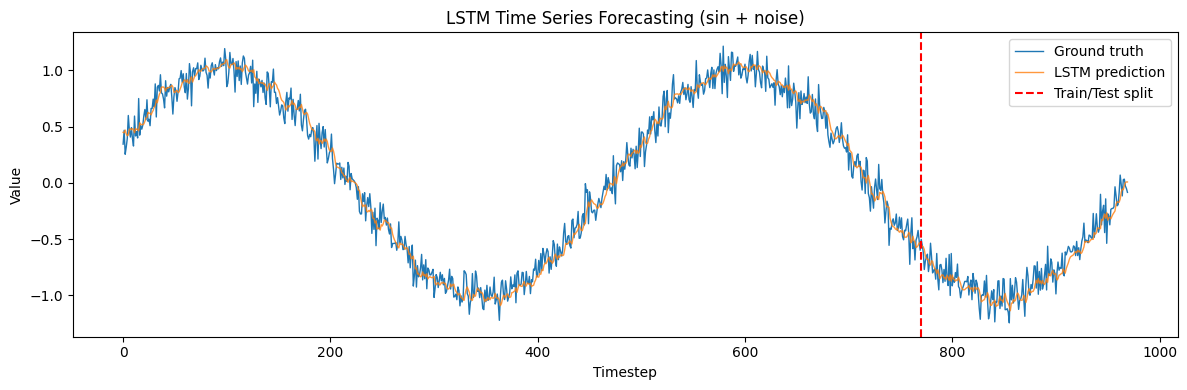

Test MSE: 0.013090


In [11]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# --- Tạo dữ liệu chuỗi thời gian ---
torch.manual_seed(42)
T = 1000
t = torch.linspace(0, 4 * torch.pi, T)
series = torch.sin(t) + 0.1 * torch.randn(T)  # sin + noise

# Chia train/test
train_size = 800
train_series = series[:train_size]
test_series  = series[train_size:]

seq_len = 30  # dùng 30 bước trước để dự đoán 1 bước tiếp

def make_sequences(data, seq_len):
    X = torch.stack([data[i:i+seq_len] for i in range(len(data) - seq_len)])
    Y = data[seq_len:]
    return X.unsqueeze(-1), Y.unsqueeze(-1)  # (N, seq_len, 1), (N, 1)

X_train, Y_train = make_sequences(train_series, seq_len)
X_test,  Y_test  = make_sequences(series, seq_len)   # dự báo toàn bộ để vẽ

# --- Mô hình ---
class TimeSeriesLSTM(nn.Module):
    def __init__(self, input_size=1, num_hiddens=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, num_hiddens, num_layers, batch_first=True)
        self.linear = nn.Linear(num_hiddens, 1)

    def forward(self, X, state=None):
        # X: (batch, seq_len, 1)
        out, state = self.lstm(X, state)   # out: (batch, seq_len, hidden)
        return self.linear(out[:, -1, :])  # chỉ lấy output ở bước cuối → (batch, 1)

ts_model = TimeSeriesLSTM(num_hiddens=64)
ts_optimizer = torch.optim.Adam(ts_model.parameters(), lr=0.001)
mse = nn.MSELoss()

# --- Huấn luyện ---
dataset = torch.utils.data.TensorDataset(X_train, Y_train)
loader  = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

for epoch in range(100):
    ts_model.train()
    total_loss = 0
    for xb, yb in loader:
        pred = ts_model(xb)
        loss = mse(pred, yb)
        ts_optimizer.zero_grad()
        loss.backward()
        ts_optimizer.step()
        total_loss += loss.item()
    if epoch % 20 == 0:
        print(f'Epoch {epoch:3d}, MSE: {total_loss/len(loader):.6f}')

# --- Dự báo & vẽ ---
ts_model.eval()
with torch.no_grad():
    preds = ts_model(X_test).squeeze().numpy()

true_vals = series[seq_len:].numpy()
time_axis = np.arange(len(true_vals))

plt.figure(figsize=(12, 4))
plt.plot(time_axis, true_vals, label='Ground truth', linewidth=1)
plt.plot(time_axis, preds,     label='LSTM prediction', linewidth=1, alpha=0.8)
plt.axvline(train_size - seq_len, color='red', linestyle='--', label='Train/Test split')
plt.legend(); plt.title('LSTM Time Series Forecasting (sin + noise)')
plt.xlabel('Timestep'); plt.ylabel('Value')
plt.tight_layout(); plt.show()

test_preds = preds[train_size - seq_len:]
test_true  = true_vals[train_size - seq_len:]
test_mse   = np.mean((test_preds - test_true) ** 2)
print(f'Test MSE: {test_mse:.6f}')